# Methods for phase extraction from respiration data

To obtain a circular representation of from time series there are four different methods implemented: `phase_hilbert()`, `phase_onepoint()`, `phase_twopoint()` and `phase_threepoint()` which all have been used in previous research. 

Choosing between these methods has implications for both the interpretation of individual phase angles and the statistical analyses that can subsequently be performed. 



In [26]:
import numpy as np
import pickle as pkl
from pyriodic.datasets import sample
from pyriodic.preproc import RawSignal
from pyriodic.viz import plot_phase_diagnostics

import matplotlib.pyplot as plt

## Load sample data
To show how to use the different methods for phase extraction, we will load the sample dataset which contains respiration data and event information. 

In [27]:
path = sample.data_path() 

with open(path, "rb") as f:
    data = pkl.load(f)

behav_data = data["behav_data"]
resp_ts, sfreq, event_samples, event_ids = data["resp_ts"], data["sfreq"], behav_data["event_samples"], behav_data["event_ids"]


In [28]:
# for quick testing, we can use a subset of the data
start_sample = event_samples[0] - 1000  # start 1000 samples before the first event

# subtract start sample from events (the first column)
event_samples -= start_sample

duration_samples = int(sfreq * 60 * 10)  # 10 minutes
resp_ts = resp_ts[start_sample:start_sample + duration_samples]

# only keep events that are within the range of the new resp_ts
keep_idx = (event_samples >= 0) & (event_samples < len(resp_ts))
event_samples = event_samples[keep_idx]
event_ids = event_ids[keep_idx]

# initialise RawSignal object
raw = RawSignal(resp_ts, fs=sfreq)

In [29]:
# initial preprocessing: bandpass filter, smoothing, and z-scoring
raw.filter_bandpass(low=0.1, high=1.0)
raw.smoothing(window_size=500) 
raw.zscore()

## Different methods

Broadly, methods for reconstructing instantaneous phase can be divided into two categories:

1. **Landmark-based methods:**  Phase is defined relative to identifiable landmarks in the signal, such as a spike in neural oscillations or the peaks and troughs of a respiratory signal. Three such methods are implemented in pyriodic; `phase_onepoint()`, `phase_twopoint()` and `phase_threepoint()`. All of these methods rely on identifying peaks of time series data. As different types of data has different characteristics, the user can specify `distance` and `prominence` parameters for the default peak finder function `scipy.signal.find_peaks()`. You can also specify a custom peak finder function by providing a callable to the `peak_finder` argument.

2. **Continuous phase estimation methods.** Rather than relying on discrete landmarks, these approaches transform the time series into a continuous complex-valued representation from which instantaneous phase can be extracted at every time point. This is implemented using the Hilbert transform through the function `phase_hilbert()`.

### Landmark-based methods


The `phase_onepoint()` method for extracting phase angles relies on detected peaks from the time series data. Phase is defined by linearly interpolating from $0$ to $2\pi$ between each peak. The peak marks the beginning of a new cycle and is assigned a phase of $0$ (equivalent to $2\pi$). 


In [30]:
PA_onepoint, peaks_onepoint = raw.phase_onepoint(prominence=0.1)

The `phase_twopoint()` method uses both peaks and troughs of the signal to define the phase angles within each respiratory cycle. Troughs are detected as the minimum point between two peaks. Phase is then linearly interpolated from $0$ to $\pi$ between a detected peak and the following trough, and from $\pi$ to $2\pi$ from that trough to the next peak. This results in two fixed anchor points per cycle: the peak is assigned a phase of $0$ (or $2\pi$), and the trough is assigned $\pi$.

In [31]:
PA_twopoint, peaks_twopoint, troughs_twopoint = raw.phase_twopoint(prominence=0.1)

The `phase_threepoint()` method extends the two-point approach by introducing an additional anchor point per respiratory cycle. In addition to inhalation and exhalation, respiration may also include periods of breath-holding or transition phases where the signal remains relatively flat. To capture this structure more explicitly, the three-point linear interpolation detects the beginning and the end of troughs. 


<div style="
    border-left: 5px solid #f0ad4e;
    background-color: #fff8e5;
    padding: 12px 16px;
    border-radius: 4px;
    margin: 1em 0;
">
    <strong>⚠️ Note</strong><br>
    This method does not work well with the sample data because it does not have a clear flat period between exhalation and inhalation. Always plot the data and verify that the detected peaks and troughs are correct before using this method.
</div>

In [32]:
PA_threepoint, peaks_threepoint, troughs_threepoint = raw.phase_threepoint()

### Continuous phase estimation methods

The Hilbert transform provides an alternative way of extracting continuous phase by constructing an analytic signal from the original time series. A key advantage of this approach is that it does not rely on landmark detection, and therefore does not require the user to specify parameters for peak detection.

Instead it assumes an approximately narrowband, sinusoidal signal, which is often violated in respiratory data. Therefore, phase angles may not align consistently with inhalation or exhalation across cycles or participants.

In [33]:
PA_hilbert = raw.phase_hilbert()

### Comparison of methods
Let's start by ccomparing the phase angle time series extracted using the different methods. The following figure shows the phase angle time series extracted using the one-point, two-point and Hilbert methods. The phase angle time series are shown for a 40 second window of data starting at 300 seconds. The peaks and troughs identified by the two-point method are also shown.

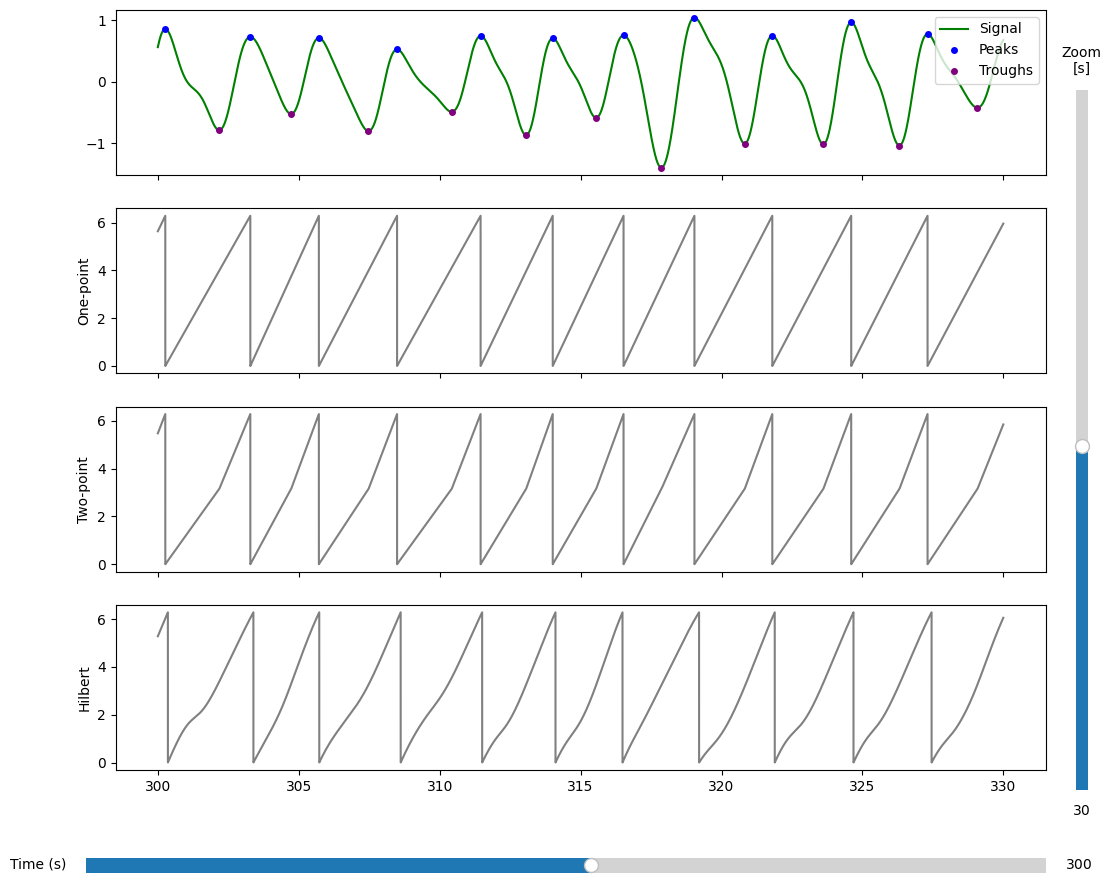

In [34]:
plot = plot_phase_diagnostics(
    {"One-point": PA_onepoint, "Two-point": PA_twopoint, "Hilbert": PA_hilbert},
    start = 300,
    window_duration = 30,
    fs = raw.fs,
    data = raw.ts,
    peaks=peaks_twopoint, # plotting the peaks and troughs from the two-point method. Same peaks are identified by the one-point method. 
    troughs=troughs_twopoint 
)

We can also look at the distribution of phase angles extracted using the different methods. The following figure shows the distribution of phase angles extracted using the `phase_onepoint()` `phase_twopoint()` and `phase_hilbert()` methods. 

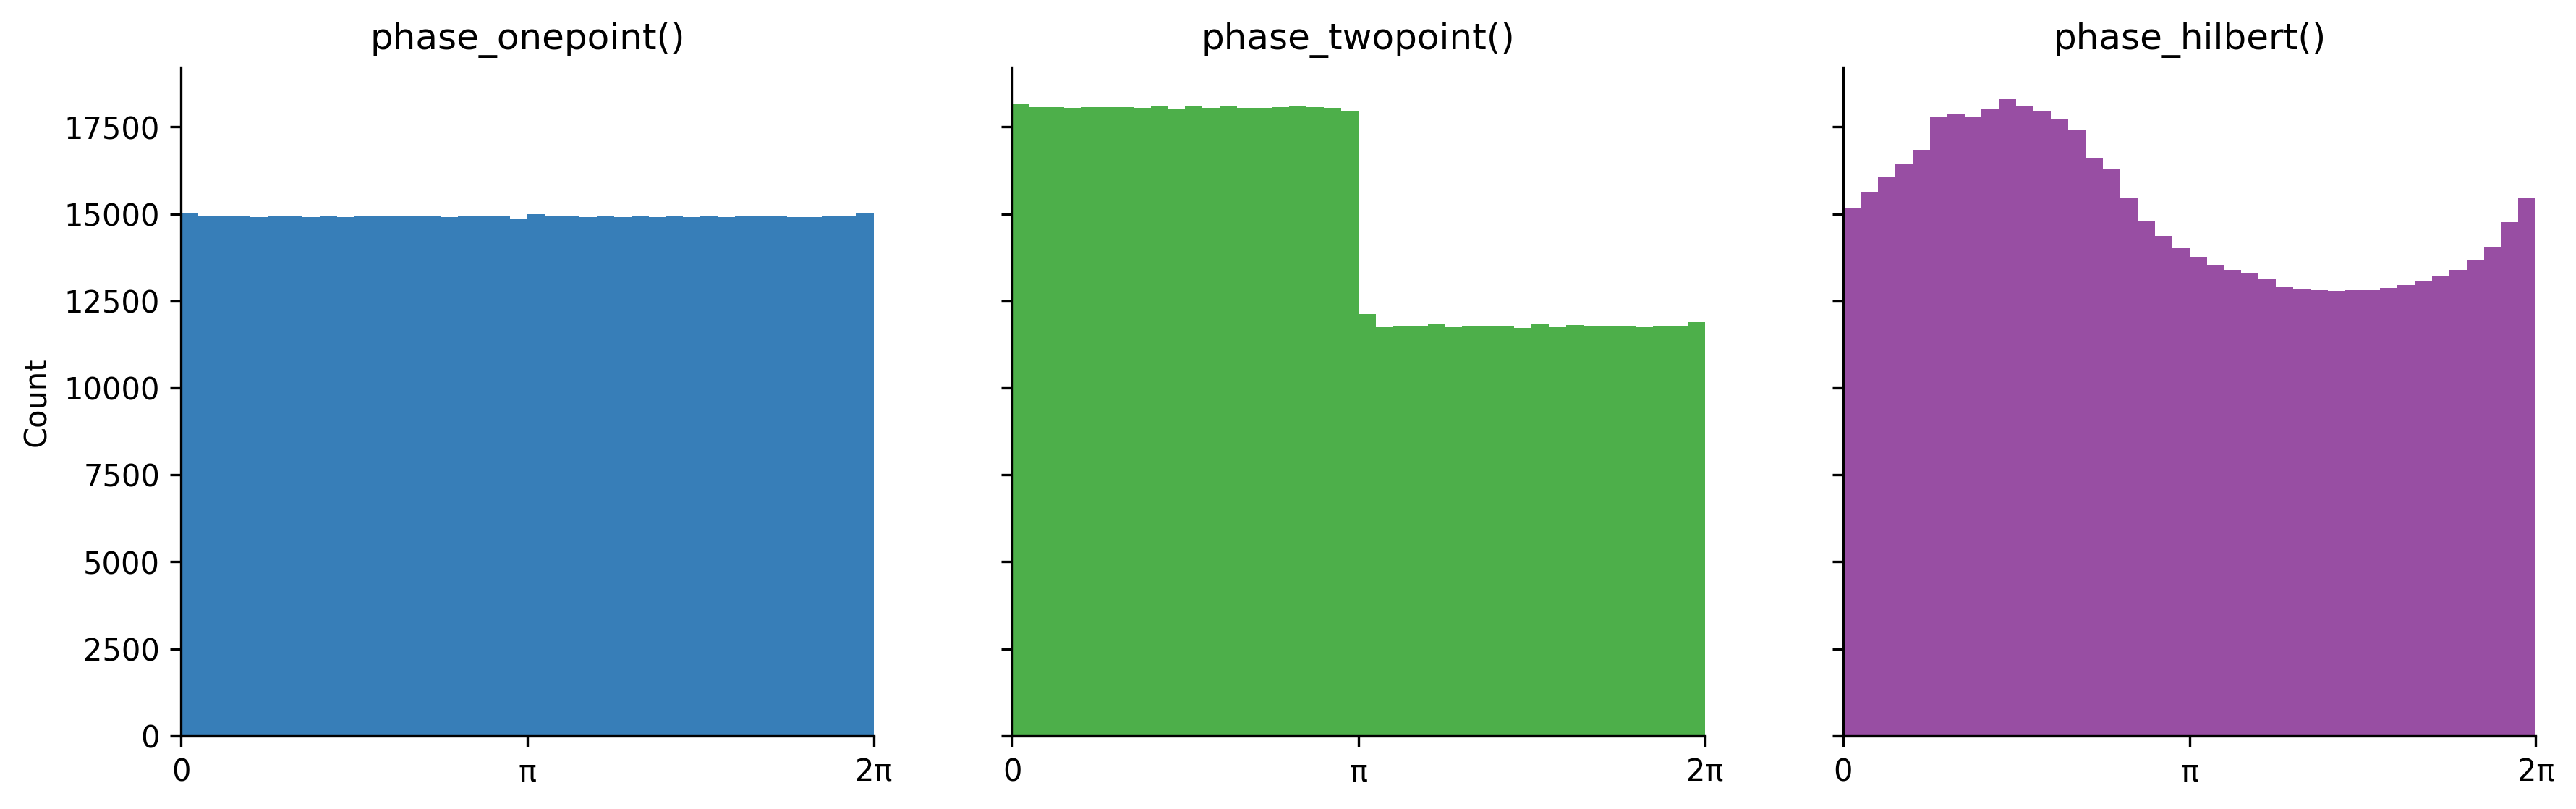

In [35]:
# histogram of phase values
phase_values = [PA_onepoint, PA_twopoint, PA_hilbert]
labels = ['phase_onepoint()', 'phase_twopoint()', 'phase_hilbert()']

fig, axes = plt.subplots(1, len(phase_values), figsize=(14, 4), sharey=True, sharex=True, dpi=300)

cmap = plt.get_cmap('Set1')
colors = [cmap(i+1) for i in range(len(phase_values))]

for phase, label, ax, color in zip(phase_values, labels, axes, colors):
    ax.hist(phase, bins=40, color=color,)
    ax.set_title(label)
    ax.set_xlim(0, 2*np.pi)

axes[0].set_xticks([0, np.pi, 2*np.pi])
axes[0].set_xticklabels(['0', 'π', '2π'])
axes[0].set_ylabel('Count')

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


In [36]:
# proportion of phase values in 0-pi and pi-2pi ranges
for phase, label in zip(phase_values, labels):
    prop_0_pi = np.sum((phase >= 0) & (phase < np.pi)) / len(phase)
    prop_pi_2pi = np.sum((phase >= np.pi) & (phase < 2*np.pi)) / len(phase)
    print(f"{label}: Proportion in [0, π): {prop_0_pi:.3f}, Proportion in [π, 2π): {prop_pi_2pi:.3f}")

phase_onepoint(): Proportion in [0, π): 0.498, Proportion in [π, 2π): 0.497
phase_twopoint(): Proportion in [0, π): 0.602, Proportion in [π, 2π): 0.393
phase_hilbert(): Proportion in [0, π): 0.554, Proportion in [π, 2π): 0.446


The `phase_onepoint()` produces a uniform distribution of phase angles, which can be useful for statistical analyses that assume that the underlying distribution is uniform. However, as only a single landmark is defined per cycle, the same phase angle can correspond to different respiratory states; for example, $\pi$ may fall within inhalation in one cycle and exhalation in another. 

Given successful peak and trough detection, `phase_twopoint()` yields a physiologically interpretable mapping in which $0$–$\pi$ corresponds to exhalation and $\pi$–$2\pi$ to inhalation. However, the resulting phase distribution is not uniform, as respiratory time is unequally distributed across inhalation and exhalation, which complicates subsequent statistical analyses.